In [1]:
!pip install pandas numpy matplotlib seaborn rasterio geopandas scikit-learn xarray rioxarray odc-stac pystac-client planetary-computer keras


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import geopandas as gpd
import xarray as xr
import rioxarray
from pystac_client import Client
from odc.stac import stac_load

In [3]:
import os

# Create 'data' folder if it doesn't exist
os.makedirs("data", exist_ok=True)

# Check if the folder is present
print("Folders in the current directory:", os.listdir())

Folders in the current directory: ['.ipynb_checkpoints', '2025_EY_Open_Science_AI_Data_Challenge_Participant_Guidance.pdf', 'Building_Footprint.kml', 'data', 'final_submission.csv', 'Landsat_LST.ipynb', 'NY_Mesonet_Weather.xlsx', 'Sentinel2_GeoTIFF.ipynb', 'Submission_template.csv', 'Training_data_uhi_index_2025-02-18.csv', 'UHI_Challenge_Dipesh.ipynb', 'UHI_Experiment_Sample_Benchmark_Notebook_V7.ipynb']


In [4]:
print(os.listdir())

['.ipynb_checkpoints', '2025_EY_Open_Science_AI_Data_Challenge_Participant_Guidance.pdf', 'Building_Footprint.kml', 'data', 'final_submission.csv', 'Landsat_LST.ipynb', 'NY_Mesonet_Weather.xlsx', 'Sentinel2_GeoTIFF.ipynb', 'Submission_template.csv', 'Training_data_uhi_index_2025-02-18.csv', 'UHI_Challenge_Dipesh.ipynb', 'UHI_Experiment_Sample_Benchmark_Notebook_V7.ipynb']


In [5]:
print("Files in data folder:", os.listdir("data"))

Files in data folder: []


In [6]:
import os

# List all files in the current directory
print("Files in root directory:", os.listdir())

Files in root directory: ['.ipynb_checkpoints', '2025_EY_Open_Science_AI_Data_Challenge_Participant_Guidance.pdf', 'Building_Footprint.kml', 'data', 'final_submission.csv', 'Landsat_LST.ipynb', 'NY_Mesonet_Weather.xlsx', 'Sentinel2_GeoTIFF.ipynb', 'Submission_template.csv', 'Training_data_uhi_index_2025-02-18.csv', 'UHI_Challenge_Dipesh.ipynb', 'UHI_Experiment_Sample_Benchmark_Notebook_V7.ipynb']


In [7]:
import pandas as pd

# Load weather data
weather_file = "NY_Mesonet_Weather.xlsx"
weather_df = pd.read_excel(weather_file, sheet_name=None)  # Load all sheets

# Show sheet names
print("Sheets in weather file:", weather_df.keys())

# Load and preview the first sheet
bronx_weather = weather_df[list(weather_df.keys())[0]]  # Load first sheet
print(bronx_weather.head())
print(bronx_weather.info())

Sheets in weather file: dict_keys(['Summary', 'Terms', 'Location', 'Bronx', 'Manhattan'])
Empty DataFrame
Columns: []
Index: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame
None


In [8]:
!pip install openpyxl


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd

# Load weather data
weather_file = "NY_Mesonet_Weather.xlsx"
weather_df = pd.read_excel(weather_file, sheet_name=None)  # Load all sheets

# Show sheet names
print("Sheets in weather file:", weather_df.keys())

# Load and preview the first sheet
bronx_weather = weather_df[list(weather_df.keys())[0]]  # Load first sheet
print(bronx_weather.head())
print(bronx_weather.info())

Sheets in weather file: dict_keys(['Summary', 'Terms', 'Location', 'Bronx', 'Manhattan'])
Empty DataFrame
Columns: []
Index: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame
None


In [10]:
for sheet in weather_df.keys():
    print(f"Sheet: {sheet} - Rows: {weather_df[sheet].shape[0]}, Columns: {weather_df[sheet].shape[1]}")

Sheet: Summary - Rows: 0, Columns: 0
Sheet: Terms - Rows: 0, Columns: 0
Sheet: Location - Rows: 0, Columns: 0
Sheet: Bronx - Rows: 169, Columns: 6
Sheet: Manhattan - Rows: 169, Columns: 6


In [11]:
bronx_weather = pd.read_excel(weather_file, sheet_name="Bronx")
print(bronx_weather.head())  # Preview first few rows
print(bronx_weather.info())  # Check data types and missing values

               Date / Time  Air Temp at Surface [degC]  \
0  2021-07-24 06:00:00 EDT                        19.3   
1  2021-07-24 06:05:00 EDT                        19.4   
2  2021-07-24 06:10:00 EDT                        19.3   
3  2021-07-24 06:15:00 EDT                        19.4   
4  2021-07-24 06:20:00 EDT                        19.4   

   Relative Humidity [percent]  Avg Wind Speed [m/s]  \
0                         88.2                   0.8   
1                         87.9                   0.8   
2                         87.6                   0.7   
3                         87.4                   0.5   
4                         87.0                   0.2   

   Wind Direction [degrees]  Solar Flux [W/m^2]  
0                       335                  12  
1                       329                  18  
2                       321                  25  
3                       307                  33  
4                       301                  42  
<class 'pandas

In [12]:
bronx_weather = pd.read_excel(weather_file, sheet_name="Bronx")
print(bronx_weather.head())  # Preview first few rows
print(bronx_weather.info())  # Check data types and missing values

               Date / Time  Air Temp at Surface [degC]  \
0  2021-07-24 06:00:00 EDT                        19.3   
1  2021-07-24 06:05:00 EDT                        19.4   
2  2021-07-24 06:10:00 EDT                        19.3   
3  2021-07-24 06:15:00 EDT                        19.4   
4  2021-07-24 06:20:00 EDT                        19.4   

   Relative Humidity [percent]  Avg Wind Speed [m/s]  \
0                         88.2                   0.8   
1                         87.9                   0.8   
2                         87.6                   0.7   
3                         87.4                   0.5   
4                         87.0                   0.2   

   Wind Direction [degrees]  Solar Flux [W/m^2]  
0                       335                  12  
1                       329                  18  
2                       321                  25  
3                       307                  33  
4                       301                  42  
<class 'pandas

In [13]:
import os

# Check if the folder is present
print("Folders in the current directory:", os.listdir())

Folders in the current directory: ['.ipynb_checkpoints', '2025_EY_Open_Science_AI_Data_Challenge_Participant_Guidance.pdf', 'Building_Footprint.kml', 'data', 'final_submission.csv', 'Landsat_LST.ipynb', 'NY_Mesonet_Weather.xlsx', 'Sentinel2_GeoTIFF.ipynb', 'Submission_template.csv', 'Training_data_uhi_index_2025-02-18.csv', 'UHI_Challenge_Dipesh.ipynb', 'UHI_Experiment_Sample_Benchmark_Notebook_V7.ipynb']


In [14]:
# Load UHI training data
uhi_file = "Training_data_uhi_index_2025-02-18.csv"
uhi_df = pd.read_csv(uhi_file)

# Preview first few rows
print(uhi_df.head())
print(uhi_df.info())  # Check data types and missing values

   Longitude   Latitude          datetime  UHI Index
0 -73.909167  40.813107  24-07-2021 15:53   1.030289
1 -73.909187  40.813045  24-07-2021 15:53   1.030289
2 -73.909215  40.812978  24-07-2021 15:53   1.023798
3 -73.909242  40.812908  24-07-2021 15:53   1.023798
4 -73.909257  40.812845  24-07-2021 15:53   1.021634
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11229 entries, 0 to 11228
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Longitude  11229 non-null  float64
 1   Latitude   11229 non-null  float64
 2   datetime   11229 non-null  object 
 3   UHI Index  11229 non-null  float64
dtypes: float64(3), object(1)
memory usage: 351.0+ KB
None


In [15]:
# Convert datetime column to proper datetime format
uhi_df["datetime"] = pd.to_datetime(uhi_df["datetime"], format="%d-%m-%Y %H:%M")

# Verify changes
print(uhi_df.dtypes)
print(uhi_df.head())

Longitude           float64
Latitude            float64
datetime     datetime64[ns]
UHI Index           float64
dtype: object
   Longitude   Latitude            datetime  UHI Index
0 -73.909167  40.813107 2021-07-24 15:53:00   1.030289
1 -73.909187  40.813045 2021-07-24 15:53:00   1.030289
2 -73.909215  40.812978 2021-07-24 15:53:00   1.023798
3 -73.909242  40.812908 2021-07-24 15:53:00   1.023798
4 -73.909257  40.812845 2021-07-24 15:53:00   1.021634


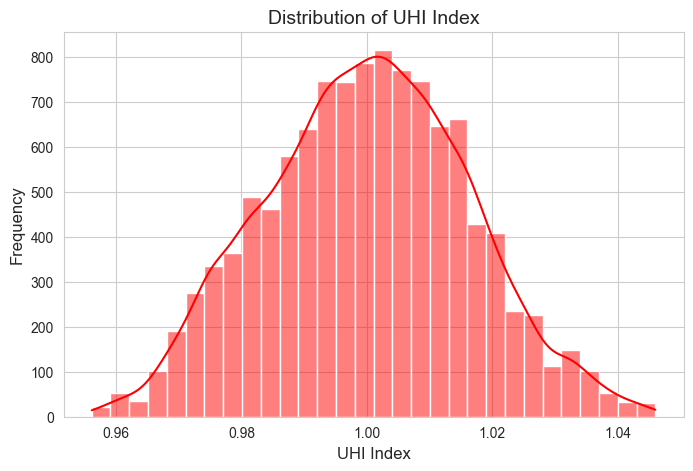

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(uhi_df["UHI Index"], bins=30, kde=True, color="red")

# Labels
plt.xlabel("UHI Index", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of UHI Index", fontsize=14)

# Show plot
plt.show()

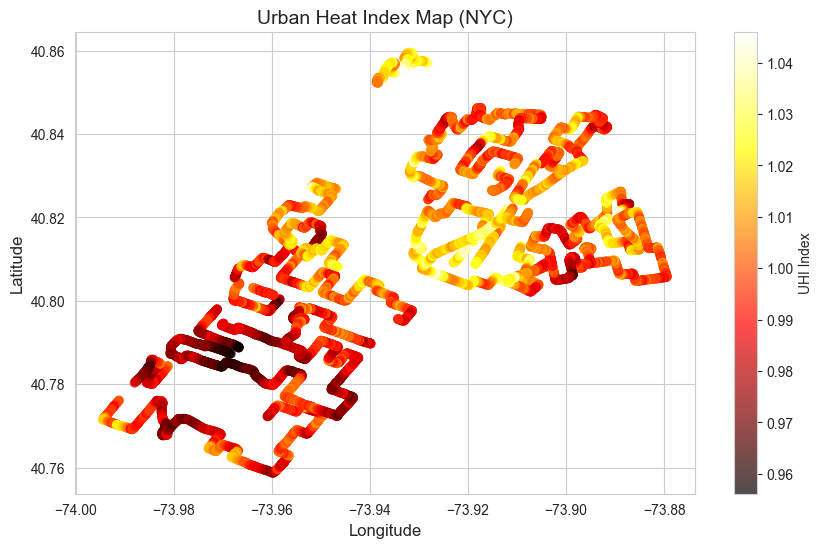

In [17]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(
    uhi_df["Longitude"], 
    uhi_df["Latitude"], 
    c=uhi_df["UHI Index"], 
    cmap="hot", 
    alpha=0.7
)

# Add colorbar
plt.colorbar(sc, label="UHI Index")

# Labels
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.title("Urban Heat Index Map (NYC)", fontsize=14)

# Show plot
plt.show()

In [18]:
# Load weather data
weather_file = "NY_Mesonet_Weather.xlsx"
weather_df = pd.read_excel(weather_file, sheet_name="Bronx")  # Adjust sheet if needed

# Remove "EDT" from Date / Time column
weather_df["Date / Time"] = weather_df["Date / Time"].str.replace(" EDT", "", regex=False)

# Convert datetime to proper format
weather_df["Date / Time"] = pd.to_datetime(weather_df["Date / Time"], format="%Y-%m-%d %H:%M:%S")

# Rename column to match UHI dataset
weather_df.rename(columns={"Date / Time": "datetime"}, inplace=True)

# Merge UHI data with weather data
merged_df = pd.merge(uhi_df, weather_df, on="datetime", how="left")

# Check merged data
print(merged_df.head())
print(merged_df.info())

   Longitude   Latitude            datetime  UHI Index  \
0 -73.909167  40.813107 2021-07-24 15:53:00   1.030289   
1 -73.909187  40.813045 2021-07-24 15:53:00   1.030289   
2 -73.909215  40.812978 2021-07-24 15:53:00   1.023798   
3 -73.909242  40.812908 2021-07-24 15:53:00   1.023798   
4 -73.909257  40.812845 2021-07-24 15:53:00   1.021634   

   Air Temp at Surface [degC]  Relative Humidity [percent]  \
0                         NaN                          NaN   
1                         NaN                          NaN   
2                         NaN                          NaN   
3                         NaN                          NaN   
4                         NaN                          NaN   

   Avg Wind Speed [m/s]  Wind Direction [degrees]  Solar Flux [W/m^2]  
0                   NaN                       NaN                 NaN  
1                   NaN                       NaN                 NaN  
2                   NaN                       NaN             

In [19]:
# Sort both dataframes by datetime
uhi_df = uhi_df.sort_values("datetime")
weather_df = weather_df.sort_values("datetime")

# Merge using nearest timestamp within a 5-minute tolerance
merged_df = pd.merge_asof(
    uhi_df, 
    weather_df, 
    on="datetime", 
    direction="nearest",  # Finds closest match
    tolerance=pd.Timedelta("5min")  # Allow matching within 5 minutes
)

# Check merged data
print(merged_df.head())
print(merged_df.info())

   Longitude   Latitude            datetime  UHI Index  \
0 -73.977157  40.771555 2021-07-24 15:01:00   0.975234   
1 -73.910167  40.803775 2021-07-24 15:01:00   1.000718   
2 -73.910268  40.803817 2021-07-24 15:01:00   1.000718   
3 -73.978742  40.771675 2021-07-24 15:01:00   0.975234   
4 -73.978453  40.771677 2021-07-24 15:01:00   0.970907   

   Air Temp at Surface [degC]  Relative Humidity [percent]  \
0                        28.0                         40.3   
1                        28.0                         40.3   
2                        28.0                         40.3   
3                        28.0                         40.3   
4                        28.0                         40.3   

   Avg Wind Speed [m/s]  Wind Direction [degrees]  Solar Flux [W/m^2]  
0                   3.0                        75                 725  
1                   3.0                        75                 725  
2                   3.0                        75             

In [20]:
# Heat Index Formula (simplified)
merged_df["Heat Index"] = merged_df["Air Temp at Surface [degC]"] + 0.05 * merged_df["Relative Humidity [percent]"]

# Check new feature
print(merged_df[["Air Temp at Surface [degC]", "Relative Humidity [percent]", "Heat Index"]].head())

   Air Temp at Surface [degC]  Relative Humidity [percent]  Heat Index
0                        28.0                         40.3      30.015
1                        28.0                         40.3      30.015
2                        28.0                         40.3      30.015
3                        28.0                         40.3      30.015
4                        28.0                         40.3      30.015


In [21]:
# Extract date-time components
merged_df["hour"] = merged_df["datetime"].dt.hour
merged_df["day_of_week"] = merged_df["datetime"].dt.dayofweek
merged_df["month"] = merged_df["datetime"].dt.month

# Check new features
print(merged_df[["datetime", "hour", "day_of_week", "month"]].head())

             datetime  hour  day_of_week  month
0 2021-07-24 15:01:00    15            5      7
1 2021-07-24 15:01:00    15            5      7
2 2021-07-24 15:01:00    15            5      7
3 2021-07-24 15:01:00    15            5      7
4 2021-07-24 15:01:00    15            5      7


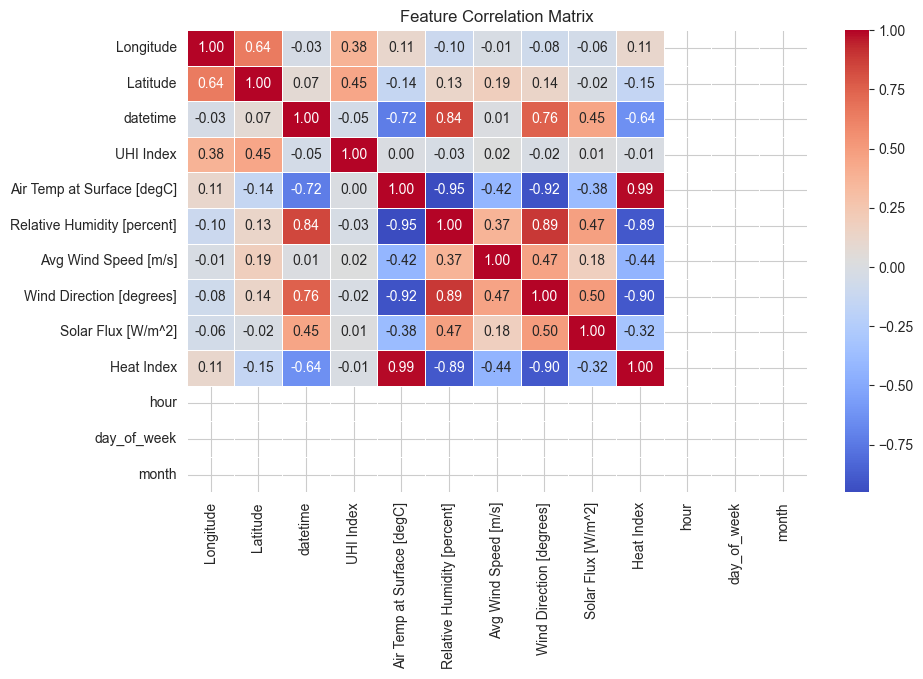

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = merged_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

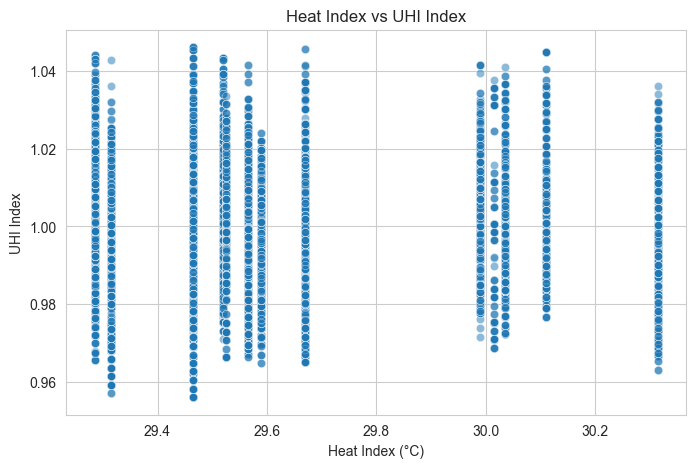

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=merged_df, x="Heat Index", y="UHI Index", alpha=0.5)

# Labels
plt.xlabel("Heat Index (°C)")
plt.ylabel("UHI Index")
plt.title("Heat Index vs UHI Index")

plt.show()

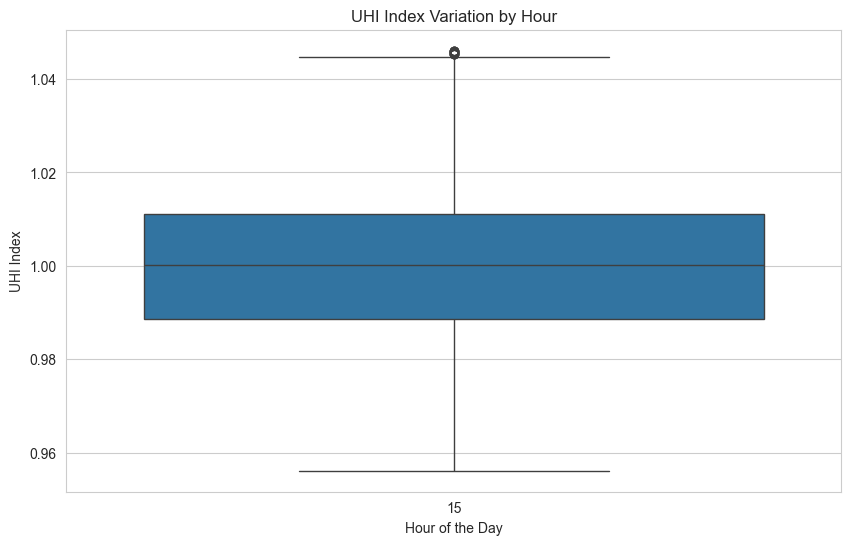

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_df, x="hour", y="UHI Index")

# Labels
plt.xlabel("Hour of the Day")
plt.ylabel("UHI Index")
plt.title("UHI Index Variation by Hour")

plt.show()

In [25]:
import geopandas as gpd

# Load KML file
building_file = "Building_Footprint.kml"
buildings = gpd.read_file(building_file)

# Preview data
print(buildings.head())
print(buildings.crs)  # Check coordinate reference system

  Name Description                                           geometry
0                   MULTIPOLYGON (((-73.91903 40.8482, -73.91933 4...
1                   MULTIPOLYGON (((-73.92195 40.84963, -73.92191 ...
2                   MULTIPOLYGON (((-73.9205 40.85011, -73.92045 4...
3                   MULTIPOLYGON (((-73.92056 40.8514, -73.92053 4...
4                   MULTIPOLYGON (((-73.91234 40.85218, -73.91247 ...
EPSG:4326


In [26]:
from shapely.geometry import Point

# Convert UHI data to GeoDataFrame
uhi_gdf = gpd.GeoDataFrame(merged_df, 
                           geometry=gpd.points_from_xy(merged_df.Longitude, merged_df.Latitude), 
                           crs="EPSG:4326")

# Count number of buildings within 100m of each UHI point
buffer_distance = 0.001  # ~100 meters in lat/lon degrees
uhi_gdf["Building Density"] = uhi_gdf.geometry.apply(
    lambda x: buildings[buildings.geometry.intersects(x.buffer(buffer_distance))].shape[0]
)

# Preview new feature
print(uhi_gdf[["Longitude", "Latitude", "Building Density"]].head())

   Longitude   Latitude  Building Density
0 -73.977157  40.771555                 1
1 -73.910167  40.803775                 1
2 -73.910268  40.803817                 1
3 -73.978742  40.771675                 4
4 -73.978453  40.771677                 4


In [27]:
print(uhi_gdf["Building Density"].describe())

count    11229.000000
mean         7.451331
std          4.692074
min          0.000000
25%          4.000000
50%          7.000000
75%          9.000000
max         32.000000
Name: Building Density, dtype: float64


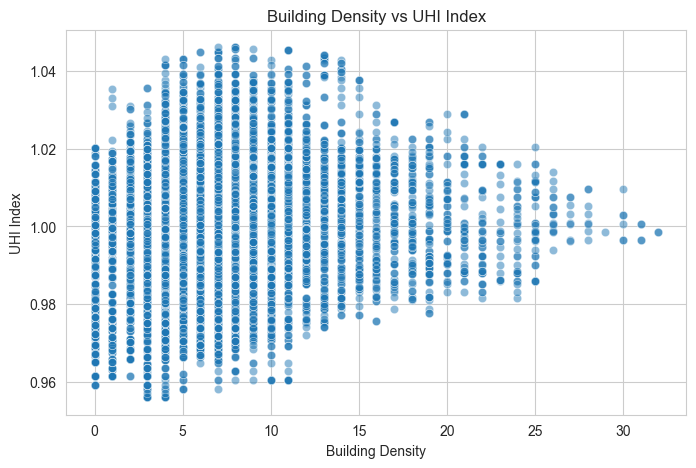

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.scatterplot(data=uhi_gdf, x="Building Density", y="UHI Index", alpha=0.5)

plt.xlabel("Building Density")
plt.ylabel("UHI Index")
plt.title("Building Density vs UHI Index")

plt.show()

In [30]:
# Compute RMSE manually
rmse = mean_squared_error(y_test, y_pred) ** 0.5  # Square root of MSE

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Select features and target
features = ["Longitude", "Latitude", "Heat Index", "Solar Flux [W/m^2]", "Air Temp at Surface [degC]", "Building Density"]
target = "UHI Index"

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(uhi_gdf[features], uhi_gdf[target], test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred = rf_model.predict(X_test)

# Evaluate Model
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5  # Fixed RMSE calculation

print(f"Model Performance:\nR² Score: {r2:.4f}\nRMSE: {rmse:.4f}")

Model Performance:
R² Score: 0.9679
RMSE: 0.0029


In [38]:
# Load submission template
submission_file = "Submission_template.csv"
submission_df = pd.read_csv(submission_file)

# Preview template structure
print(submission_df.head())

   Longitude   Latitude  UHI Index
0 -73.971665  40.788763        NaN
1 -73.971928  40.788875        NaN
2 -73.967080  40.789080        NaN
3 -73.972550  40.789082        NaN
4 -73.969697  40.787953        NaN


In [41]:
# Load submission template again
submission_file = "Submission_template.csv"
submission_df = pd.read_csv(submission_file)

# Merge submission template with necessary features from training data
submission_data = submission_df.merge(
    uhi_gdf[["Longitude", "Latitude", "Heat Index", "Solar Flux [W/m^2]", "Air Temp at Surface [degC]", "Building Density"]],
    on=["Longitude", "Latitude"],
    how="left"
)

# Check if there are missing values
print(submission_data.isna().sum())

Longitude                        0
Latitude                         0
UHI Index                     1040
Heat Index                    1040
Solar Flux [W/m^2]            1040
Air Temp at Surface [degC]    1040
Building Density              1040
dtype: int64


In [42]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Find rows with missing values
missing_rows = submission_data[submission_data["Heat Index"].isna()]

if not missing_rows.empty:
    print(f"⚠️ Found {len(missing_rows)} missing feature rows. Filling using nearest neighbors...")

    # Use Longitude & Latitude to find nearest neighbors in training data
    nn_model = NearestNeighbors(n_neighbors=1)
    nn_model.fit(uhi_gdf[["Longitude", "Latitude"]])

    # Find nearest neighbors for missing rows
    distances, indices = nn_model.kneighbors(missing_rows[["Longitude", "Latitude"]])

    # Fill missing values with nearest neighbor data
    for i, idx in enumerate(indices.flatten()):
        submission_data.loc[missing_rows.index[i], ["Heat Index", "Solar Flux [W/m^2]", "Air Temp at Surface [degC]", "Building Density"]] = (
            uhi_gdf.iloc[idx][["Heat Index", "Solar Flux [W/m^2]", "Air Temp at Surface [degC]", "Building Density"]].values
        )

# Check if missing values are fixed
print(submission_data.isna().sum())

⚠️ Found 1040 missing feature rows. Filling using nearest neighbors...
Longitude                        0
Latitude                         0
UHI Index                     1040
Heat Index                       0
Solar Flux [W/m^2]               0
Air Temp at Surface [degC]       0
Building Density                 0
dtype: int64


In [43]:
# Predict UHI Index
submission_data["UHI Index"] = rf_model.predict(submission_data[["Longitude", "Latitude", "Heat Index", "Solar Flux [W/m^2]", "Air Temp at Surface [degC]", "Building Density"]])

# Keep only required columns
submission_final = submission_data[["Longitude", "Latitude", "UHI Index"]]

# Save to CSV for submission
submission_final.to_csv("final_submission.csv", index=False)

print("✅ Final submission file generated: final_submission.csv")

✅ Final submission file generated: final_submission.csv


In [44]:
import pandas as pd

# Load the submission file
submission_final = pd.read_csv("final_submission.csv")

# Preview first few rows
print(submission_final.head())

   Longitude   Latitude  UHI Index
0 -73.971665  40.788763   0.963609
1 -73.971928  40.788875   0.964399
2 -73.967080  40.789080   0.963393
3 -73.972550  40.789082   0.962727
4 -73.969697  40.787953   0.958210


In [45]:
print(submission_final.isna().sum())

Longitude    0
Latitude     0
UHI Index    0
dtype: int64


In [46]:
print(f"Total Rows: {submission_final.shape[0]}")
print(f"Total Columns: {submission_final.shape[1]}")

Total Rows: 1040
Total Columns: 3


In [47]:
print(f"UHI Index Min: {submission_final['UHI Index'].min()}")
print(f"UHI Index Max: {submission_final['UHI Index'].max()}")

UHI Index Min: 0.958068908489999
UHI Index Max: 1.0433553367499997


In [48]:
# Updated feature set (removing Latitude & Longitude)
valid_features = ["Heat Index", "Solar Flux [W/m^2]", "Air Temp at Surface [degC]", "Building Density"]
target = "UHI Index"

# Split data
X_train, X_val, y_train, y_val = train_test_split(uhi_gdf[valid_features], uhi_gdf[target], test_size=0.2, random_state=42)

# Train updated Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on validation set
y_pred_val = rf_model.predict(X_val)

# Evaluate model
r2 = r2_score(y_val, y_pred_val)
rmse = mean_squared_error(y_val, y_pred_val, squared=False)

print(f"✅ Updated Model Performance:\nR² Score: {r2:.4f}\nRMSE: {rmse:.4f}")

TypeError: got an unexpected keyword argument 'squared'

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from math import sqrt

# Updated feature set (removing Latitude & Longitude)
valid_features = ["Heat Index", "Solar Flux [W/m^2]", "Air Temp at Surface [degC]", "Building Density"]
target = "UHI Index"

# Split data
X_train, X_val, y_train, y_val = train_test_split(uhi_gdf[valid_features], uhi_gdf[target], test_size=0.2, random_state=42)

# Train updated Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on validation set
y_pred_val = rf_model.predict(X_val)

# Evaluate model
r2 = r2_score(y_val, y_pred_val)
rmse = sqrt(mean_squared_error(y_val, y_pred_val))

print(f"✅ Updated Model Performance:\nR² Score: {r2:.4f}\nRMSE: {rmse:.4f}")

✅ Updated Model Performance:
R² Score: 0.1432
RMSE: 0.0150


In [50]:
uhi_gdf["Wind_X"] = uhi_gdf["Avg Wind Speed [m/s]"] * np.cos(np.deg2rad(uhi_gdf["Wind Direction [degrees]"]))
uhi_gdf["Wind_Y"] = uhi_gdf["Avg Wind Speed [m/s]"] * np.sin(np.deg2rad(uhi_gdf["Wind Direction [degrees]"]))

# New feature set
enhanced_features = ["Heat Index", "Solar Flux [W/m^2]", "Air Temp at Surface [degC]", "Building Density", "hour", "day_of_week", "month", "Wind_X", "Wind_Y"]
target = "UHI Index"

# Split data
X_train, X_val, y_train, y_val = train_test_split(uhi_gdf[enhanced_features], uhi_gdf[target], test_size=0.2, random_state=42)

# Train updated Random Forest model
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on validation set
y_pred_val = rf_model.predict(X_val)

# Evaluate model
r2 = r2_score(y_val, y_pred_val)
rmse = sqrt(mean_squared_error(y_val, y_pred_val))

print(f"✅ Enhanced Model Performance:\nR² Score: {r2:.4f}\nRMSE: {rmse:.4f}")

✅ Enhanced Model Performance:
R² Score: 0.1438
RMSE: 0.0150


In [51]:
!pip install xgboost

   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB 495.5 kB/s eta 0:04:13
   ---------------------------------------- 0.5/124.9 MB 4.2 MB/s eta 0:00:30
   ---------------------------------------- 1.0/124.9 MB 6.5 MB/s eta 0:00:20
   ---------------------------------------- 1.5/124.9 MB 7.3 MB/s eta 0:00:17
    --------------------------------------- 2.0/124.9 MB 8.1 MB/s eta 0:00:16
    --------------------------------------- 2.6/124.9 MB 8.7 MB/s eta 0:00:15
   - -------------------------------------- 3.2/124.9 MB 9.4 MB/s eta 0:00:13
   - -------------------------------------- 3.8/124.9 MB 9.7 MB/s eta 0:00:13
   - -------------------------------------- 4.2/124.9 MB 9.6 MB/s eta 0:00:13
   - -------------------------------------- 4.7/124.9 MB 9.7 MB/s eta 0:00:13
   - -------------------------------------- 5.2/124.9 MB 10.0 MB/s eta 0:00:


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
import xgboost as xgb

# Create DMatrix for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

# XGBoost parameters
params = {
    "objective": "reg:squarederror",
    "max_depth": 10,
    "learning_rate": 0.05,
    "n_estimators": 200,
    "colsample_bytree": 0.8,
    "subsample": 0.8,
    "seed": 42
}

# Train XGBoost model
xgb_model = xgb.train(params, dtrain, num_boost_round=200)

# Predict on validation set
y_pred_val = xgb_model.predict(dval)

# Evaluate model
r2 = r2_score(y_val, y_pred_val)
rmse = sqrt(mean_squared_error(y_val, y_pred_val))

print(f"✅ XGBoost Model Performance:\nR² Score: {r2:.4f}\nRMSE: {rmse:.4f}")

ValueError: feature_names must be string, and may not contain [, ] or <

In [54]:
import xgboost as xgb

# Create DMatrix for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

# XGBoost parameters
params = {
    "objective": "reg:squarederror",
    "max_depth": 10,
    "learning_rate": 0.05,
    "n_estimators": 200,
    "colsample_bytree": 0.8,
    "subsample": 0.8,
    "seed": 42
}

# Train XGBoost model
xgb_model = xgb.train(params, dtrain, num_boost_round=200)

# Predict on validation set
y_pred_val = xgb_model.predict(dval)

# Evaluate model
r2 = r2_score(y_val, y_pred_val)
rmse = sqrt(mean_squared_error(y_val, y_pred_val))

print(f"✅ XGBoost Model Performance:\nR² Score: {r2:.4f}\nRMSE: {rmse:.4f}")

ValueError: feature_names must be string, and may not contain [, ] or <

In [55]:
import xgboost as xgb

# Create DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

# XGBoost parameters
params = {
    "objective": "reg:squarederror",
    "max_depth": 10,
    "learning_rate": 0.05,
    "n_estimators": 200,
    "colsample_bytree": 0.8,
    "subsample": 0.8,
    "seed": 42
}

# Train model
xgb_model = xgb.train(params, dtrain, num_boost_round=200)

# Predict and evaluate
y_pred_val = xgb_model.predict(dval)
r2 = r2_score(y_val, y_pred_val)
rmse = sqrt(mean_squared_error(y_val, y_pred_val))

print(f"✅ XGBoost Model Performance:\nR² Score: {r2:.4f}\nRMSE: {rmse:.4f}")

ValueError: feature_names must be string, and may not contain [, ] or <